<a href="https://colab.research.google.com/github/sayma-code/Artificial-Intelligence-and-Smart-Energy/blob/main/Midterm_Question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from scipy.signal import savgol_filter

In [ ]:
np.random.seed(42)

hours = 24 * 200  # 200 days of hourly data
time = np.arange(hours)
# Base price pattern (daily sinusoidal + random trend)
price = 40 + 10 * np.sin(2 * np.pi * time / 24) + 0.05 * time

In [ ]:
# Add random noise
price += np.random.normal(0, 2, size=hours)

In [ ]:
# Create DataFrame
df = pd.DataFrame({
    "price": price,
    "load": 300 + 50 * np.sin(2 * np.pi * time / 24 + 1),
    "temperature": 10 + 5 * np.sin(2 * np.pi * time / (24 * 30)),
    "generation": 500 + 40 * np.sin(2 * np.pi * time / 24 + 2),
})

In [ ]:
# Introduce missing values artificially
df.iloc[100:110, 0] = np.nan

In [ ]:
# (a) Handle missing values
df["price"].fillna(method="ffill", inplace=True)

/tmp/ipykernel_19783/3715268729.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(method="ffill", inplace=True)
/tmp/ipykernel_19783/3715268729.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["price"].fillna(method="ffill", inplace=True)


In [ ]:
# (b) Remove outliers using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df["price"] = np.clip(df["price"], lower, upper)

In [ ]:
# (c) Denoising using Savitzky–Golay filter (preserves shape)
df["price"] = savgol_filter(df["price"], window_length=11, polyorder=2)

In [ ]:
# (d) Normalization
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

In [ ]:
def create_dataset(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, 0])  # predict next-hour price
    return np.array(X), np.array(y)

window_size = 24
X, y = create_dataset(scaled, window_size)

In [ ]:
# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# Build LSTM Model
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(window_size, scaled.shape[1])),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0067 - val_loss: 2.0836e-04
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.0459e-05 - val_loss: 1.6081e-04
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3377e-05 - val_loss: 7.0921e-05
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2347e-05 - val_loss: 1.1588e-04
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0614e-05 - val_loss: 5.0337e-05
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0235e-05 - val_loss: 1.7992e-04
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2706e-05 - val_loss: 1.1729e-04
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1341e-05 - val_loss: 6.3778e-05
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4082e-05 - val_loss: 4.2615e-05
Epoch 10/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9052e-05 - val_loss: 3.3076e-05
Epoch 11/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9966e-05 - val_lo

In [ ]:
y_pred = model.predict(X_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
# Inverse transform
dummy = np.zeros((len(y_pred), scaled.shape[1]))
dummy[:, 0] = y_pred[:, 0]
y_pred_real = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), scaled.shape[1]))
dummy2[:, 0] = y_test
y_test_real = scaler.inverse_transform(dummy2)[:, 0]

In [ ]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 5.868636439228242
MAE: 5.445866571642038


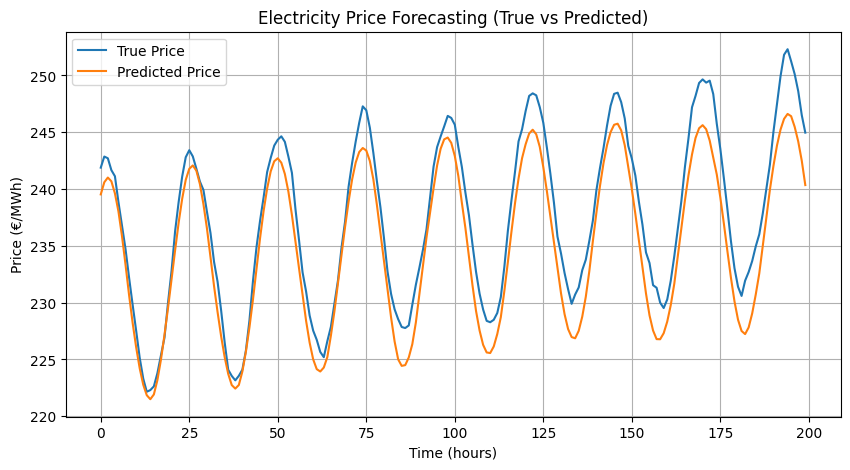

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_real[:200], label="True Price")
plt.plot(y_pred_real[:200], label="Predicted Price")
plt.title("Electricity Price Forecasting (True vs Predicted)")
plt.xlabel("Time (hours)")
plt.ylabel("Price (€/MWh)")
plt.legend()
plt.grid(True)
plt.show()